# Análisis Discriminante — Capítulo 12
### Díaz & Morales (2012) · Rencher (2002)
**Maestría en Ciencias — Estadística · Universidad Nacional de Colombia**

---

| Sección | Contenido |
|---|---|
| 1 | Importaciones y datos |
| 2 | Función discriminante de Fisher (cálculo manual) |
| 3 | Discriminación Lineal (LDA) |
| 4 | Discriminación Cuadrática (QDA) |
| 5 | Comparación LDA vs QDA — frontera de clasificación |
| 6 | Discriminación Logística |
| 7 | Clasificación bayesiana — probabilidades a posteriori |
| 8 | Distancia de Mahalanobis y K-NN |
| 9 | Tasas de error: resustitución vs validación cruzada (LOO) |
| 10 | Resumen final |


---
## 1. Importaciones y configuración

In [2]:
import sys
!{sys.executable} -m pip install scikit-learn numpy matplotlib scipy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy import linalg
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# Paleta de colores
C1, C2, C3 = "#C0392B", "#2980B9", "#27AE60"
FONDO = "#F8F9FA"

plt.rcParams.update({
    "figure.facecolor": FONDO,
    "axes.facecolor":   FONDO,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size": 11,
})

print("✓ Librerías cargadas correctamente")

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 21.1 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
✓ Librerías cargadas correctamente


### 1.1 Datos — Ejemplo 12.2.1: Senil / No Senil
*(Morrison 1990, pág. 143 — citado en Díaz & Morales)*

**Variables:** X₁=Información, X₂=Similaridades, X₃=Aritmética, X₄=Habilidad Artística  
**Grupos:** No Senil (n₁=37) · Senil (n₂=12)  
**Supuesto:** distribución normal 4-variante con matriz de covarianzas común Σ


In [3]:
# Medias de los grupos (Tabla 12.1)
media_no_senil = np.array([12.57, 9.57, 11.49, 7.97])
media_senil    = np.array([ 8.75, 5.33,  8.50, 4.75])
n1_senil, n2_senil = 37, 12

# Matriz de covarianzas común Spl (dada en el libro, pág. 450)
S = np.array([
    [11.255,  9.404,  7.149,  3.383],
    [ 9.404, 13.532,  7.383,  2.553],
    [ 7.149,  7.383, 11.574,  2.617],
    [ 3.383,  2.553,  2.617,  5.809]
])

# Generamos datos coherentes con medias y S para poder graficar
np.random.seed(42)
X_no_senil = np.random.multivariate_normal(media_no_senil, S, n1_senil)
X_senil    = np.random.multivariate_normal(media_senil,    S, n2_senil)
X_senil_all = np.vstack([X_no_senil, X_senil])
y_senil_all = np.array([0]*n1_senil + [1]*n2_senil)  # 0=No Senil, 1=Senil

# Nueva observación del libro (pág. 451)
X0 = np.array([10, 8, 7, 5])

print("Medias No Senil:", media_no_senil)
print("Medias Senil:   ", media_senil)
print("Nueva obs. X₀  :", X0)

Medias No Senil: [12.57  9.57 11.49  7.97]
Medias Senil:    [8.75 5.33 8.5  4.75]
Nueva obs. X₀  : [10  8  7  5]


### 1.2 Datos — Ejercicio 3, Tabla 12.7
Dos poblaciones normales trivariadas (X₁, X₂, X₃).  
**Nueva observación:** X₀ = [26.71, 17.04, 25.73]


In [4]:
pob1 = np.array([
    [29.72,10.80,34.50],[29.98,18.57,25.24],[33.97, 9.26,23.49],
    [32.11,12.95,21.59],[27.38,10.78,28.75],[26.28, 6.48,22.88],
    [37.26,17.81,33.43],[28.18,11.76,21.94],[34.90,23.97,30.95],
    [30.24,10.14,25.94],[33.61, 7.00,24.09],[30.02,20.12,14.23],
    [30.20,14.58,22.89],[27.47,16.10,28.06],[29.53,13.01,24.40],
])
pob2 = np.array([
    [14.56, 6.34,15.68],[ 8.35, 5.30,10.53],[17.00, 8.23,15.53],
    [21.31, 3.74,16.20],[ 4.99, 6.12,18.14],[19.41, 2.58,13.44],
    [18.37,18.84, 4.09],[18.14, 9.63,12.50],[20.26,15.87,13.72],
    [14.07, 4.52,12.94],[22.59,18.09,17.26],[20.85,16.85,15.22],
])

X_ej3 = np.vstack([pob1, pob2])
y_ej3 = np.array([1]*len(pob1) + [2]*len(pob2))
x_nueva = np.array([26.71, 17.04, 25.73])

print(f"Pob. 1: n={len(pob1)}  |  Pob. 2: n={len(pob2)}")
print(f"Nueva observación: {x_nueva}")

Pob. 1: n=15  |  Pob. 2: n=12
Nueva observación: [26.71 17.04 25.73]


---
## 2. Función discriminante de Fisher — Ejemplo 12.2.1

La función discriminante de Fisher busca la dirección **a** que maximiza la separación entre grupos relativa a la dispersión interna:

$$\max_a \frac{(\bar{z}_1 - \bar{z}_2)^2}{s_z^2} = \max_a \frac{[a'(\bar{y}_1-\bar{y}_2)]^2}{a'S_{pl}a}$$

La solución es:
$$\boxed{a = S_{pl}^{-1}(\bar{y}_1 - \bar{y}_2)}$$

Se asigna a **No Senil** si $Y = b'X \geq Y_c$, y a **Senil** si $Y < Y_c$, donde $Y_c = \frac{1}{2}(\bar{Y}_1 + \bar{Y}_2)$.


In [5]:
# Cálculo manual de la función discriminante de Fisher
d     = media_no_senil - media_senil       # diferencia de medias
S_inv = np.linalg.inv(S)
b     = S_inv @ d                          # a = Spl⁻¹(ȳ₁ − ȳ₂)

# Punto de corte
Yc = 0.5 * (b @ media_no_senil + b @ media_senil)

# Valor para la nueva observación
Y_X0 = b @ X0

print("=" * 50)
print("  Coeficientes  b = Spl⁻¹(ȳ₁ − ȳ₂)")
print("=" * 50)
for i, (bi, xi) in enumerate(zip(b, ["Información","Similaridades","Aritmética","Hab. Artística"]), 1):
    print(f"  b{i} ({xi:<16}): {bi:.4f}")

print(f"\nPunto de corte  Yc = {Yc:.4f}  (libro: 4.7512 ✓)")
print(f"\nNueva obs. X₀ = {X0}")
print(f"Y = b'X₀ = {Y_X0:.4f}")
print(f"\n→ Como {Y_X0:.4f} < {Yc:.4f}  →  Se clasifica como: SENIL  ✓")

  Coeficientes  b = Spl⁻¹(ȳ₁ − ȳ₂)
  b1 (Información     ): 0.0299
  b2 (Similaridades   ): 0.2036
  b3 (Aritmética      ): 0.0098
  b4 (Hab. Artística  ): 0.4430

Punto de corte  Yc = 4.7511  (libro: 4.7512 ✓)

Nueva obs. X₀ = [10  8  7  5]
Y = b'X₀ = 4.2115

→ Como 4.2115 < 4.7511  →  Se clasifica como: SENIL  ✓


In [6]:
# Coeficientes estandarizados (para interpretar importancia de variables)
# a*r = sr * br   donde sr = sqrt(Spl[r,r])
sr   = np.sqrt(np.diag(S))
b_std = sr * b

print("Coeficientes estandarizados  a*ᵣ = sᵣ · bᵣ")
print("(miden cuánto cambia Y por 1 desviación estándar en cada variable)\n")
for i, (v, vs, nom) in enumerate(
        zip(b, b_std, ["Información","Similaridades","Aritmética","Hab. Artística"]), 1):
    print(f"  X{i} {nom:<16}  b={v:.4f}   b*={vs:.4f}")

# D² y T²
D2 = d @ S_inv @ d
T2 = (n1_senil * n2_senil) / (n1_senil + n2_senil) * D2
print(f"\nDistancia de Mahalanobis  D² = {D2:.4f}")
print(f"Estadístico T²               = {T2:.4f}")

Coeficientes estandarizados  a*ᵣ = sᵣ · bᵣ
(miden cuánto cambia Y por 1 desviación estándar en cada variable)

  X1 Información       b=0.0299   b*=0.1002
  X2 Similaridades     b=0.2036   b*=0.7491
  X3 Aritmética        b=0.0098   b*=0.0334
  X4 Hab. Artística    b=0.4430   b*=1.0677

Distancia de Mahalanobis  D² = 2.4333
Estadístico T²               = 22.0490


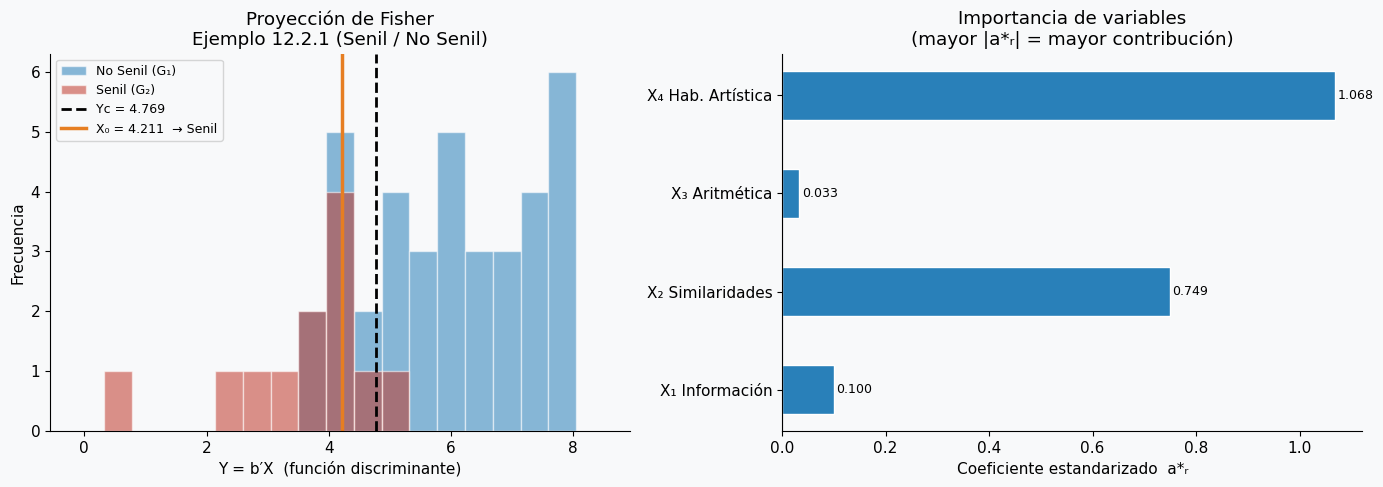

In [7]:
# ── Gráfica: proyección Fisher + coeficientes estandarizados ──
Y1 = X_no_senil @ b
Y2 = X_senil    @ b
Y1bar, Y2bar = Y1.mean(), Y2.mean()
Yc_val = (Y1bar + Y2bar) / 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogramas solapados
bins = np.linspace(min(Y1.min(), Y2.min())-0.5, max(Y1.max(), Y2.max())+0.5, 20)
ax1.hist(Y1, bins=bins, alpha=0.55, color=C2, label="No Senil (G₁)", edgecolor="white")
ax1.hist(Y2, bins=bins, alpha=0.55, color=C1, label="Senil (G₂)",    edgecolor="white")
ax1.axvline(Yc_val, color="black",   lw=2.0, ls="--", label=f"Yc = {Yc_val:.3f}")
ax1.axvline(b @ X0, color="#E67E22", lw=2.5, ls="-",
            label=f"X₀ = {b@X0:.3f}  → Senil")
ax1.set_xlabel("Y = b′X  (función discriminante)")
ax1.set_ylabel("Frecuencia")
ax1.set_title("Proyección de Fisher\nEjemplo 12.2.1 (Senil / No Senil)")
ax1.legend(fontsize=9)

# Coeficientes estandarizados
nombres = ["X₁ Información","X₂ Similaridades","X₃ Aritmética","X₄ Hab. Artística"]
colores = [C2 if v >= 0 else C1 for v in b_std]
bars = ax2.barh(nombres, b_std, color=colores, edgecolor="white", height=0.5)
ax2.axvline(0, color="gray", lw=0.8)
for bar, val in zip(bars, b_std):
    ax2.text(val + 0.005*np.sign(val), bar.get_y()+bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)
ax2.set_xlabel("Coeficiente estandarizado  a*ᵣ")
ax2.set_title("Importancia de variables\n(mayor |a*ᵣ| = mayor contribución)")

plt.tight_layout()
plt.show()

---
## 3. Discriminación Lineal (LDA) — Ejercicio 3

La regla lineal asume **Σ₁ = Σ₂ = Σ** (homocedasticidad).  
Se asigna X al grupo que maximice:

$$D_i = \ln(p_i) - \frac{1}{2}(X-\bar{X}_i)'S_{pl}^{-1}(X-\bar{X}_i)$$

La frontera de decisión $D_{12} = 0$ es una **recta** (hiperplano en p dimensiones).


In [8]:
# Ajuste LDA
lda = LDA(solver='lsqr')
lda.fit(X_ej3, y_ej3)

y_pred_lda = lda.predict(X_ej3)
tea_lda    = np.mean(y_pred_lda != y_ej3)

# Clasificar nueva observación
pred_lda   = lda.predict([x_nueva])[0]
proba_lda  = lda.predict_proba([x_nueva])[0]

print("── Función discriminante lineal ──")
print(f"  Coeficientes β: {np.round(lda.coef_[0], 4)}")
print(f"  Intercepto  α:  {lda.intercept_[0]:.4f}")
print(f"\n── Clasificación de X₀ = {x_nueva} ──")
print(f"  Asignada a: Población {pred_lda}")
print(f"  P(G₁|X) = {proba_lda[0]:.4f}   P(G₂|X) = {proba_lda[1]:.4f}")
print(f"\nTasa de error aparente (TEA): {tea_lda:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_ej3, y_pred_lda, labels=[1,2])
print("\nMatriz de confusión (resustitución):")
print(f"  Real\\Pred   G₁   G₂")
print(f"  G₁         {cm[0,0]:3d}  {cm[0,1]:3d}")
print(f"  G₂         {cm[1,0]:3d}  {cm[1,1]:3d}")

── Función discriminante lineal ──
  Coeficientes β: [-0.8366  0.1019 -0.5134]
  Intercepto  α:  28.4934

── Clasificación de X₀ = [26.71 17.04 25.73] ──
  Asignada a: Población 1
  P(G₁|X) = 0.9952   P(G₂|X) = 0.0048

Tasa de error aparente (TEA): 0.0000

Matriz de confusión (resustitución):
  Real\Pred   G₁   G₂
  G₁          15    0
  G₂           0   12


---
## 4. Discriminación Cuadrática (QDA) — Ejercicio 3

Cuando **Σ₁ ≠ Σ₂**, la función de clasificación es:

$$Q_i(X) = \ln(p_i) - \frac{1}{2}\ln|S_i| - \frac{1}{2}(X-\bar{X}_i)'S_i^{-1}(X-\bar{X}_i)$$

El término $X'\Lambda X$ (con $\Lambda = S_1^{-1}-S_2^{-1}$) **no se cancela**, generando una frontera **curva**.  

> Con n pequeño, Rencher recomienda LDA aunque Σ₁ ≠ Σ₂ porque QDA es menos estable.


In [9]:
# Verificar si las matrices difieren
S1 = np.cov(pob1, rowvar=False)
S2 = np.cov(pob2, rowvar=False)
n1, n2 = len(pob1), len(pob2)

print("── Diagnóstico de homocedasticidad ──")
print(f"  |S₁| = {np.linalg.det(S1):.2f}   Traza(S₁) = {np.trace(S1):.2f}")
print(f"  |S₂| = {np.linalg.det(S2):.2f}   Traza(S₂) = {np.trace(S2):.2f}")
print("  → Las matrices difieren → QDA es teóricamente apropiada")
print("  → Pero con n₁=15, n₂=12 pequeños → LDA sigue siendo más estable\n")

# Ajuste QDA
qda = QDA()
qda.fit(X_ej3, y_ej3)

y_pred_qda = qda.predict(X_ej3)
tea_qda    = np.mean(y_pred_qda != y_ej3)
pred_qda   = qda.predict([x_nueva])[0]
proba_qda  = qda.predict_proba([x_nueva])[0]

print("── Clasificación QDA de X₀ ──")
print(f"  Asignada a: Población {pred_qda}")
print(f"  P(G₁|X) = {proba_qda[0]:.4f}   P(G₂|X) = {proba_qda[1]:.4f}")
print(f"  TEA = {tea_qda:.4f}")

── Diagnóstico de homocedasticidad ──
  |S₁| = 5029.66   Traza(S₁) = 60.32
  |S₂| = 10352.90   Traza(S₂) = 79.17
  → Las matrices difieren → QDA es teóricamente apropiada
  → Pero con n₁=15, n₂=12 pequeños → LDA sigue siendo más estable

── Clasificación QDA de X₀ ──
  Asignada a: Población 1
  P(G₁|X) = 0.9991   P(G₂|X) = 0.0009
  TEA = 0.0000


---
## 5. Fronteras de clasificación — LDA vs QDA

Visualización en 2D usando X₁ y X₂. La región azul corresponde a Pob. 1, la roja a Pob. 2.  
La línea negra es la **frontera de decisión**.


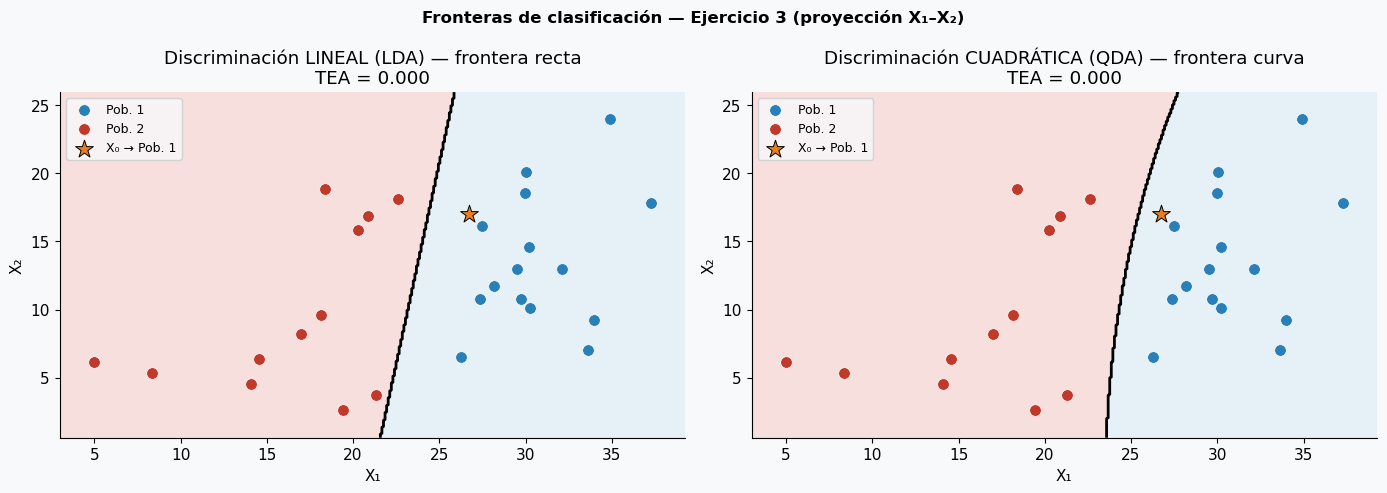

In [10]:
X2d = X_ej3[:, :2]
lda_2d = LDA(solver='lsqr'); lda_2d.fit(X2d, y_ej3)
qda_2d = QDA();              qda_2d.fit(X2d, y_ej3)

x_min, x_max = X2d[:,0].min()-2, X2d[:,0].max()+2
y_min, y_max = X2d[:,1].min()-2, X2d[:,1].max()+2
xx, yy = np.meshgrid(np.linspace(x_min,x_max,400), np.linspace(y_min,y_max,400))
grid   = np.c_[xx.ravel(), yy.ravel()]
cmap_b = ListedColormap(["#AED6F1","#F1948A"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, modelo, titulo in zip(
    axes,
    [lda_2d, qda_2d],
    ["Discriminación LINEAL (LDA) — frontera recta",
     "Discriminación CUADRÁTICA (QDA) — frontera curva"]
):
    Z = modelo.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap_b)
    ax.contour(xx, yy, Z, levels=[1.5], colors="black", linewidths=2)
    for g, c, l in [(1, C2, "Pob. 1"), (2, C1, "Pob. 2")]:
        m = (y_ej3 == g)
        ax.scatter(X2d[m,0], X2d[m,1], c=c, s=70, edgecolors="white",
                   linewidths=0.5, label=l, zorder=3)
    ax.scatter(x_nueva[0], x_nueva[1], c="#E67E22", s=180, marker="*",
               edgecolors="black", linewidths=0.7,
               label=f"X₀ → Pob. {modelo.predict([x_nueva[:2]])[0]}", zorder=5)
    tea = np.mean(modelo.predict(X2d) != y_ej3)
    ax.set_title(f"{titulo}\nTEA = {tea:.3f}")
    ax.set_xlabel("X₁"); ax.set_ylabel("X₂")
    ax.legend(fontsize=9)

plt.suptitle("Fronteras de clasificación — Ejercicio 3 (proyección X₁–X₂)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 6. Discriminación Logística

Para distribuciones multinormales con Σ₁=Σ₂, el log de la razón de densidades es **lineal**:

$$\ln\frac{f(y|G_1)}{f(y|G_2)} = \alpha + \beta' y$$

La probabilidad a posteriori toma la forma **logística**:

$$P(G_1|y) = \frac{1}{1+e^{-(\alpha_0+\beta'y)}}$$

Se asigna a G₁ si $\alpha + \beta'y > \ln(p_1/p_2)$.


In [11]:
log_mod = LogisticRegression(max_iter=500)
log_mod.fit(X_ej3, y_ej3)

pred_log  = log_mod.predict([x_nueva])[0]
proba_log = log_mod.predict_proba([x_nueva])[0]
tea_log   = np.mean(log_mod.predict(X_ej3) != y_ej3)

print("── Modelo logístico ──")
print(f"  β (coeficientes): {np.round(log_mod.coef_[0], 4)}")
print(f"  α (intercepto):   {log_mod.intercept_[0]:.4f}")
print(f"\n── Clasificación de X₀ ──")
print(f"  Puntaje lineal α+β'X₀ = {x_nueva @ log_mod.coef_[0] + log_mod.intercept_[0]:.4f}")
print(f"  Asignada a: Población {pred_log}")
print(f"  P(G₁|X) = {proba_log[0]:.4f}   P(G₂|X) = {proba_log[1]:.4f}")
print(f"  TEA = {tea_log:.4f}")

── Modelo logístico ──
  β (coeficientes): [-0.8502  0.031  -0.3497]
  α (intercepto):   27.0894

── Clasificación de X₀ ──
  Puntaje lineal α+β'X₀ = -4.0870
  Asignada a: Población 1
  P(G₁|X) = 0.9835   P(G₂|X) = 0.0165
  TEA = 0.0000


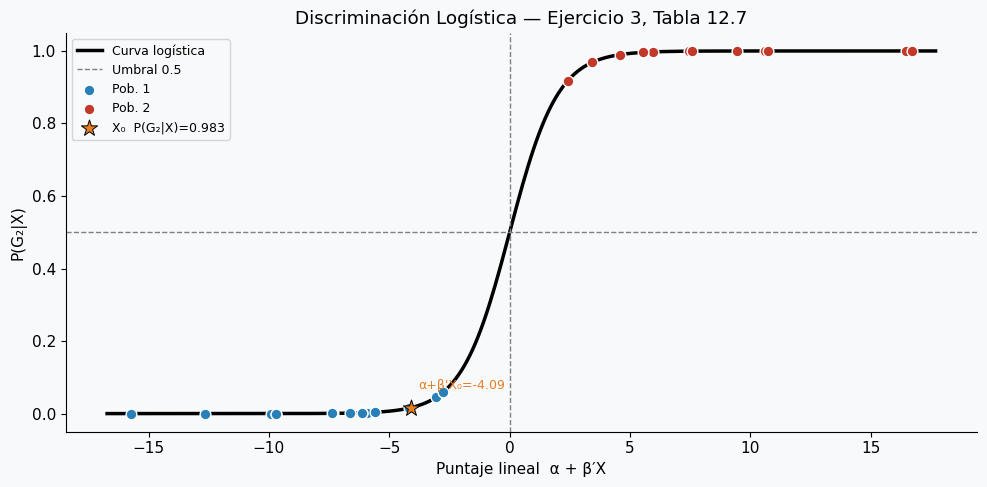

In [12]:
# Curva logística
coef_l  = log_mod.coef_[0]
inter_l = log_mod.intercept_[0]
z_vals  = X_ej3 @ coef_l + inter_l
logit_v = 1 / (1 + np.exp(-z_vals))

z_grid     = np.linspace(z_vals.min()-1, z_vals.max()+1, 300)
logit_grid = 1 / (1 + np.exp(-z_grid))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(z_grid, logit_grid, color="black", lw=2.5, label="Curva logística")
ax.axhline(0.5, color="gray", ls="--", lw=1, label="Umbral 0.5")
ax.axvline(0,   color="gray", ls="--", lw=1)
for g, c, l in [(1, C2, "Pob. 1"), (2, C1, "Pob. 2")]:
    m = (y_ej3 == g)
    ax.scatter(z_vals[m], logit_v[m], c=c, s=60, edgecolors="white", label=l, zorder=3)

z_nueva  = x_nueva @ coef_l + inter_l
p_nueva  = 1 / (1 + np.exp(-z_nueva))
ax.scatter([z_nueva], [p_nueva], c="#E67E22", s=150, marker="*",
           edgecolors="black", linewidths=0.7,
           label=f"X₀  P(G₂|X)={1-p_nueva:.3f}", zorder=5)
ax.annotate(f"α+β'X₀={z_nueva:.2f}", xy=(z_nueva, p_nueva),
            xytext=(z_nueva+0.3, p_nueva+0.05), fontsize=9, color="#E67E22")

ax.set_xlabel("Puntaje lineal  α + β′X")
ax.set_ylabel("P(G₂|X)")
ax.set_title("Discriminación Logística — Ejercicio 3, Tabla 12.7")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 7. Clasificación Bayesiana — Probabilidades a posteriori

Con probabilidades a priori $p_i$, se asigna X al grupo con mayor probabilidad a posteriori:

$$P(G_i|X) = \frac{p_i f_i(X)}{\sum_j p_j f_j(X)}$$

La **regla de máxima verosimilitud** es el caso especial con $p_1 = p_2$ (priors iguales).


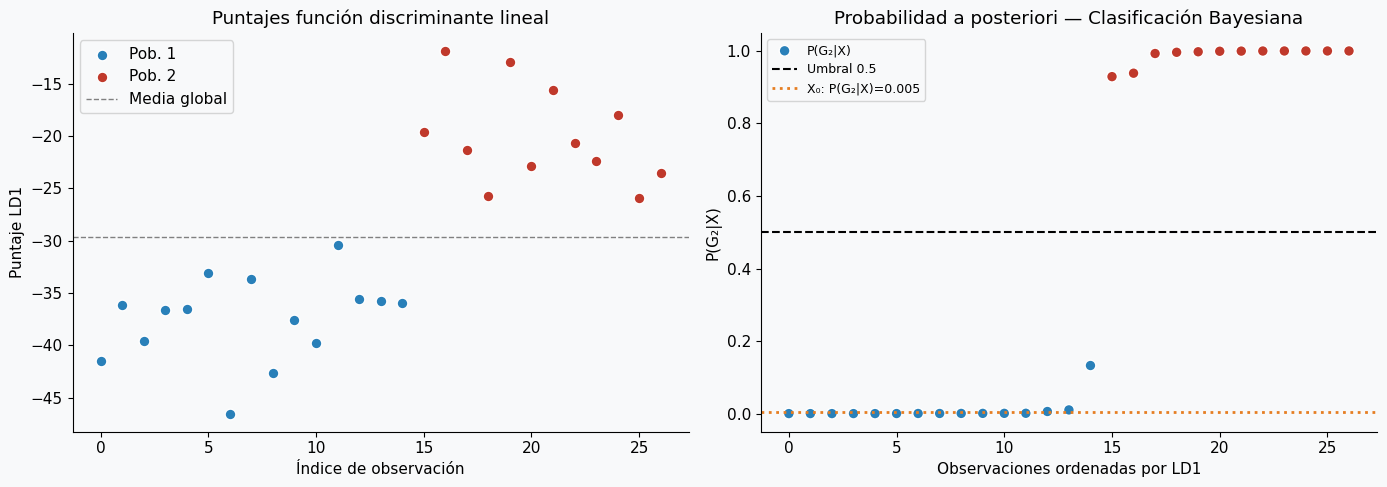

Nueva obs. X₀: P(G₁|X)=0.9952  P(G₂|X)=0.0048
→ Asignada a Población 1 (mayor probabilidad a posteriori)


In [13]:
# Puntajes LD1 y probabilidades a posteriori (LDA)
Y_all  = X_ej3 @ lda.coef_[0]
probs  = lda.predict_proba(X_ej3)
orden  = np.argsort(Y_all)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Puntajes por grupo
for g, c, l in [(1, C2, "Pob. 1"), (2, C1, "Pob. 2")]:
    m = (y_ej3 == g)
    ax1.scatter(np.where(m)[0], Y_all[m], c=c, s=60,
                edgecolors="white", label=l)
ax1.axhline(Y_all.mean(), color="gray", ls="--", lw=1, label="Media global")
ax1.set_xlabel("Índice de observación")
ax1.set_ylabel("Puntaje LD1")
ax1.set_title("Puntajes función discriminante lineal")
ax1.legend()

# P(G₂|X) ordenado
colores_ord = [C1 if g==2 else C2 for g in y_ej3[orden]]
ax2.scatter(range(len(orden)), probs[orden, 1],
            c=colores_ord, s=60, edgecolors="white", label="P(G₂|X)")
ax2.axhline(0.5, color="black", ls="--", lw=1.5, label="Umbral 0.5")
p_nueva_bayes = lda.predict_proba([x_nueva])[0]
ax2.axhline(p_nueva_bayes[1], color="#E67E22", ls=":", lw=2,
            label=f"X₀: P(G₂|X)={p_nueva_bayes[1]:.3f}")
ax2.set_xlabel("Observaciones ordenadas por LD1")
ax2.set_ylabel("P(G₂|X)")
ax2.set_title("Probabilidad a posteriori — Clasificación Bayesiana")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Nueva obs. X₀: P(G₁|X)={p_nueva_bayes[0]:.4f}  P(G₂|X)={p_nueva_bayes[1]:.4f}")
print(f"→ Asignada a Población 1 (mayor probabilidad a posteriori)")

---
## 8. Distancia de Mahalanobis y K-NN

La clasificación por **mínima distancia de Mahalanobis** asigna X al centroide más cercano:

$$D_i^2 = (X - \bar{X}_i)'S_{pl}^{-1}(X-\bar{X}_i)$$

El método **K-NN** examina los k vecinos más cercanos y asigna X al grupo mayoritario.  
Valor recomendado: $k \approx \sqrt{n_i}$.


── Distancias Mahalanobis — nueva observación ──
  D²(X₀, G₁) = 2.2604
  D²(X₀, G₂) = 11.7135
  → Asignada a G₁ ✓


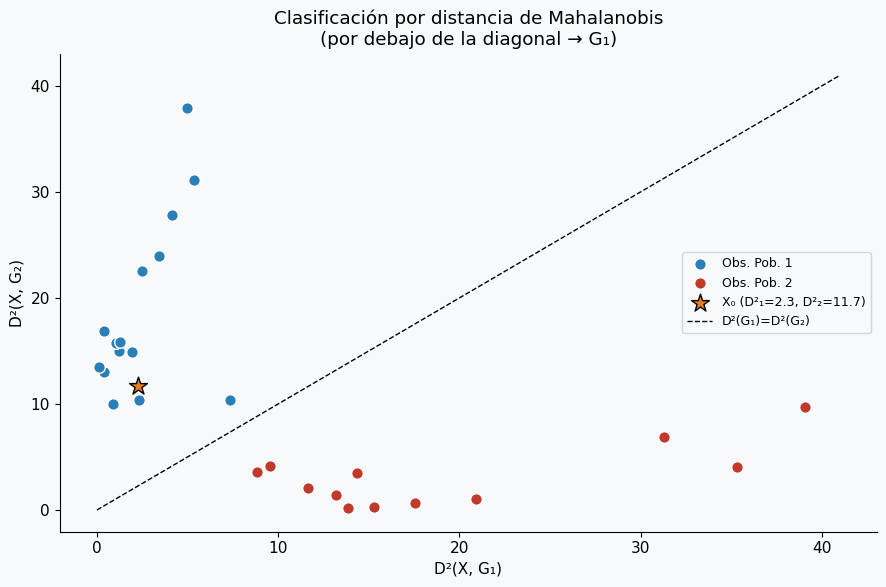

In [14]:
# Matrices y centroides
S1 = np.cov(pob1, rowvar=False)
S2 = np.cov(pob2, rowvar=False)
Spl_ej3 = ((n1-1)*S1 + (n2-1)*S2) / (n1+n2-2)
Spl_inv = np.linalg.inv(Spl_ej3)
mu1, mu2 = pob1.mean(0), pob2.mean(0)

def maha(x, mu, Sinv):
    d = x - mu
    return float(d @ Sinv @ d)

# Distancias para todas las obs.
d1_G1 = [maha(x, mu1, Spl_inv) for x in pob1]
d1_G2 = [maha(x, mu2, Spl_inv) for x in pob1]
d2_G1 = [maha(x, mu1, Spl_inv) for x in pob2]
d2_G2 = [maha(x, mu2, Spl_inv) for x in pob2]
d_new_G1 = maha(x_nueva, mu1, Spl_inv)
d_new_G2 = maha(x_nueva, mu2, Spl_inv)

print("── Distancias Mahalanobis — nueva observación ──")
print(f"  D²(X₀, G₁) = {d_new_G1:.4f}")
print(f"  D²(X₀, G₂) = {d_new_G2:.4f}")
print(f"  → Asignada a {'G₁ ✓' if d_new_G1 <= d_new_G2 else 'G₂'}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(d1_G1, d1_G2, c=C2, s=70, edgecolors="white", label="Obs. Pob. 1", zorder=3)
ax.scatter(d2_G1, d2_G2, c=C1, s=70, edgecolors="white", label="Obs. Pob. 2", zorder=3)
ax.scatter([d_new_G1],[d_new_G2], c="#E67E22", s=180, marker="*",
           edgecolors="black", label=f"X₀ (D²₁={d_new_G1:.1f}, D²₂={d_new_G2:.1f})", zorder=5)
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim],[0, lim],"k--", lw=1, label="D²(G₁)=D²(G₂)")
ax.set_xlabel("D²(X, G₁)"); ax.set_ylabel("D²(X, G₂)")
ax.set_title("Clasificación por distancia de Mahalanobis\n(por debajo de la diagonal → G₁)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
# K-NN
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_ej3, y_ej3)
pred_knn  = knn.predict([x_nueva])[0]
proba_knn = knn.predict_proba([x_nueva])[0]
loo = LeaveOneOut()
cv_knn = 1 - cross_val_score(KNeighborsClassifier(n_neighbors=k),
                              X_ej3, y_ej3, cv=loo, scoring='accuracy').mean()

print(f"── K-NN  (k={k}, sqrt(n)≈{int(np.sqrt(len(pob1)))}) ──")
print(f"  Nueva obs. → Población {pred_knn}")
print(f"  P(G₁|X) = {proba_knn[0]:.4f}   P(G₂|X) = {proba_knn[1]:.4f}")
print(f"  Tasa de error LOO = {cv_knn:.4f}")

── K-NN  (k=3, sqrt(n)≈3) ──
  Nueva obs. → Población 1
  P(G₁|X) = 1.0000   P(G₂|X) = 0.0000
  Tasa de error LOO = 0.0370


---
## 9. Tasas de error: resustitución vs. validación cruzada (LOO)

| Estimador | Descripción | Sesgo |
|---|---|---|
| **TEA** (resustitución) | Clasifica los mismos datos del ajuste | Optimista (subestima el error real) |
| **LOO** (leave-one-out) | Construye la regla con N−1 obs., clasifica la omitida, repite N veces | Casi insesgado |



  LDA             TEA=0.0000   LOO=0.0370
  QDA             TEA=0.0000   LOO=0.0370
  Logística       TEA=0.0000   LOO=0.0370
  K-NN k=3        TEA=0.0370   LOO=0.0370


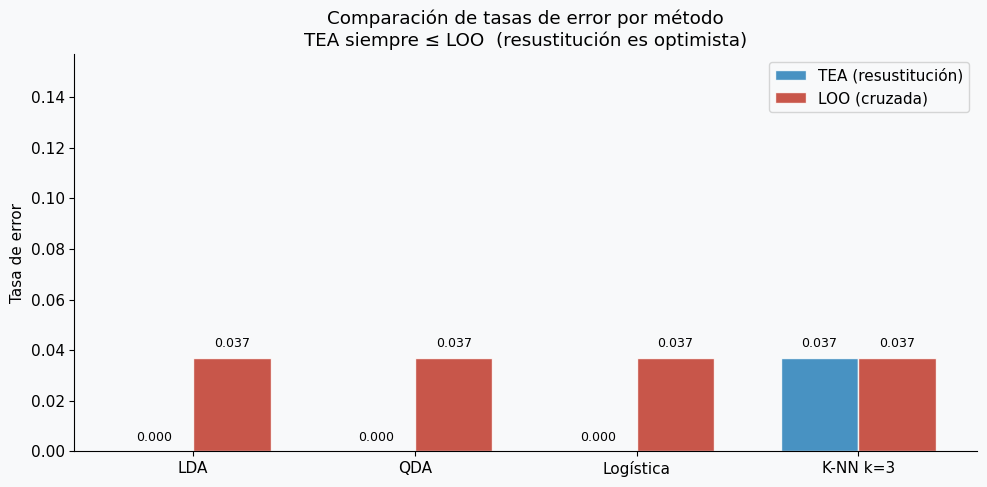

In [16]:
loo = LeaveOneOut()

resultados = {}
for nombre, modelo_cls in [
    ("LDA",       LDA(solver='lsqr')),
    ("QDA",       QDA()),
    ("Logística", LogisticRegression(max_iter=500)),
    ("K-NN k=3",  KNeighborsClassifier(n_neighbors=3)),
]:
    modelo_cls.fit(X_ej3, y_ej3)
    tea = np.mean(modelo_cls.predict(X_ej3) != y_ej3)
    cv  = 1 - cross_val_score(modelo_cls, X_ej3, y_ej3,
                               cv=loo, scoring='accuracy').mean()
    resultados[nombre] = (tea, cv)
    print(f"  {nombre:<14}  TEA={tea:.4f}   LOO={cv:.4f}")

# Gráfica comparativa
metodos   = list(resultados.keys())
tea_vals  = [resultados[m][0] for m in metodos]
loo_vals  = [resultados[m][1] for m in metodos]
x_pos = np.arange(len(metodos))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x_pos-w/2, tea_vals, w, label="TEA (resustitución)", color=C2, alpha=0.85, edgecolor="white")
b2 = ax.bar(x_pos+w/2, loo_vals, w, label="LOO (cruzada)",       color=C1, alpha=0.85, edgecolor="white")
for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.003, f"{h:.3f}",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(x_pos); ax.set_xticklabels(metodos)
ax.set_ylabel("Tasa de error")
ax.set_title("Comparación de tasas de error por método\n"
             "TEA siempre ≤ LOO  (resustitución es optimista)")
ax.legend()
ax.set_ylim(0, max(max(tea_vals),max(loo_vals))+0.12)
plt.tight_layout()
plt.show()

---
## 10. Resumen final

### Ejemplo 12.2.1 (Senil / No Senil)
- Función discriminante: **Y = 0.030X₁ + 0.204X₂ + 0.010X₃ + 0.443X₄**
- Punto de corte: **Yc = 4.7512**
- X₀ = (10, 8, 7, 5) → Y = 4.2115 < 4.7512 → **Senil** ✓

### Ejercicio 3 — Tabla 12.7


In [17]:
print("Nueva observación X₀ =", x_nueva)
print()
print(f"  {'Método':<22}  {'Asignación':<14}  P(G₁|X)   P(G₂|X)")
print(f"  {'─'*22}  {'─'*14}  {'─'*8}  {'─'*8}")

lda_f = LDA(solver='lsqr'); lda_f.fit(X_ej3, y_ej3)
qda_f = QDA();              qda_f.fit(X_ej3, y_ej3)
log_f = LogisticRegression(max_iter=500); log_f.fit(X_ej3, y_ej3)
knn_f = KNeighborsClassifier(n_neighbors=3); knn_f.fit(X_ej3, y_ej3)

for nombre, modelo_f in [("LDA (lineal)", lda_f), ("QDA (cuadrática)", qda_f),
                          ("Logística", log_f), ("K-NN (k=3)", knn_f)]:
    pred  = modelo_f.predict([x_nueva])[0]
    proba = modelo_f.predict_proba([x_nueva])[0]
    print(f"  {nombre:<22}  Población {pred:<5}       {proba[0]:.4f}    {proba[1]:.4f}")

print()
print("→ Consenso: todos los métodos asignan X₀ a Población 1")
print("→ Las probabilidades a posteriori son muy altas (>98%)")
print("   lo que indica separación clara entre los dos grupos.")

Nueva observación X₀ = [26.71 17.04 25.73]

  Método                  Asignación      P(G₁|X)   P(G₂|X)
  ──────────────────────  ──────────────  ────────  ────────
  LDA (lineal)            Población 1           0.9952    0.0048
  QDA (cuadrática)        Población 1           0.9991    0.0009
  Logística               Población 1           0.9835    0.0165
  K-NN (k=3)              Población 1           1.0000    0.0000

→ Consenso: todos los métodos asignan X₀ a Población 1
→ Las probabilidades a posteriori son muy altas (>98%)
   lo que indica separación clara entre los dos grupos.


---
### Conceptos clave para recordar

| Concepto | Regla / Fórmula |
|---|---|
| Fisher (2 grupos) | $a = S_{pl}^{-1}(\bar{y}_1-\bar{y}_2)$, asignar si $Y \gtrless Y_c$ |
| LDA (k grupos) | Maximizar $a'Ha / a'Ea$ → valores propios de $E^{-1}H$ |
| QDA | Usar $S_i$ de cada grupo; frontera curva |
| Bayes | Asignar al grupo con mayor $p_i f_i(X)$ |
| Logística | $P(G_1|y) = 1/(1+e^{-(\alpha_0+\beta'y)})$ |
| K-NN | Votación entre k vecinos más cercanos (distancia Mahalanobis) |
| TEA | Optimista — subestima el error real |
| LOO | Casi insesgado — preferido con muestras pequeñas |
